<a href="https://colab.research.google.com/github/LalithAditya0802/STAT-7220-Applied-Experimental-Design/blob/main/Applied_Experimental_Design_HW3_Lalith_Aditya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# === COURSE REPO SETUP === #
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "LalithAditya0802"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
   print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
   print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Assignments/HW3"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/LalithAditya0802/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/LalithAditya0802/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/HW3


# STAT 7220 - Homework 3
## Factorial Designs
## Dr. Austin Brown
## Due Date: November 21, 2025

## Part 1 Instructions:

A running shoe manufacturer wants to optimize the comfort of a new shoe model. They've identified three factors they believe will affect comfort:

| Factor | Level 1 (-) Description | Level 2 (+) Description |
|------------------------|------------------------|-------------------------|
| Sole Material (A) | Standard EVA foam | Advanced gel-infused foam |
| Insole Thickness (B) | 3mm | 6mm |
| Fabric Breathability (C) | Standard woven fabric | High-performance mesh fabric |

To evaluate the comfort of the $2^3=8$ runs, the manufacturer will recruit 3 NCAA division one cross-country athletes to test a randomly assigned shoe. Each athlete will run on a treadmill for 30 minutes in the shoes and rate the comfort on a scale of 1-10 (1 = very uncomfortable, 10 = very comfortable). The results of this experiment are contained in the `Shoe Comfort Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.

**Ans**:

To determine how shoe design choices affect comfort and to find the combination of:

- Sole material (EVA vs gel-infused),

- Insole thickness (3mm vs 6mm),

- Fabric breathability (woven vs mesh)

That maximizes average comfort for runners.

2.  Specify the outcome variable and how it is measured.

**Ans**:

Outcome variable: comfort

- Measurement: A numerical comfort rating (continuous scale) given by testers after wearing each shoe configuration. Values in the dataset range roughly from about 5.2 to 11.2, so it's a subjective rating scale but treated as continuous for ANOVA.

3.  Specify the independent variables. What lurking variables may be present?

**Ans**:
Independent variables (factors):

- Sole Material (A): EVA vs gel-infused foam

- Insole Thickness (B): 3mm vs 6mm

- Fabric Breathability (C): woven vs mesh

- Possible lurking / nuisance variables (not explicitly controlled in the data):

- Individual runner differences (foot shape, sensitivity, fitness, gait)

- Order / fatigue effects (which shoe they wore first, tiredness)

- Running surface or environment (track vs treadmill, temperature)

Sock type, time of day, mood

Small manufacturing differences between pairs

If these aren't blocked or randomized properly, they can add noise and potentially bias.

4.  Explain the difference between a full factorial design and a $2^k$ factorial design. Briefly comment on why the latter may be preferred in this case.

**Ans**:

A full $2^3$ factorial design:

Includes all 8 combinations of (sole, thickness, breathability).

With one observation per combination, you can estimate main effects and interactions but you cannot estimate pure error separately from model lack-of-fit.

A full factorial with replication (what you actually have):

Still includes all 8 combinations, but with 3 replicates of each.

Replication allows:

Estimation of pure error (within-condition variability)

More powerful tests of main effects and interactions

Ability to check model assumptions using residuals

Why the replicated version is preferred here: Comfort ratings are noisy and subjective; replicates give a better estimate of the true mean comfort for each design and allow meaningful ANOVA and diagnostics.

5.  State the sets of null and alternative hypotheses for this experiment.

**Ans**:

For the full $2^3$ factorial:

Let A = sole material, B = insole thickness, C = breathability.

Main Effects


H0A : No effect of sole material
(mean comfort is the same for EVA and Gel)


H1A: At least one sole material mean differs.


H0B: No effect of insole thickness


H0C: No effect of breathability

Two-way Interactions

H0AB: No A×B interaction (effect of sole material does not depend on insole thickness)

H0AC: No A×C interaction

H0BC: No B×C interaction

Three-way Interaction

H0ABC: No A×B×C interaction

For each, the alternative H1 is “at least one contrast involving that effect is non-zero.”

6.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?

**Answer**:

Exploratory data analysis was conducted to visually examine how the three design factors—sole material, insole thickness, and breathability—affect comfort ratings before fitting the ANOVA model.

A series of visualizations were generated, including boxplots for each main factor, bar plots of group means, full treatment-combination boxplots, scatterplots, and interaction plots.

Main Effects
Sole Material (EVA vs Gel)

Both boxplots and bar charts show that the Gel sole material yields noticeably higher comfort ratings than EVA. The median and interquartile range shift upward, and the distributions have minimal overlap.
This provides strong evidence against the null hypothesis of no effect.

Insole Thickness (3mm vs 6mm)

Comfort ratings are consistently higher for 6mm insoles compared to 3mm. The difference is visible in both means and distributional shifts.
This again supports the alternative hypothesis that thickness affects comfort.

Breathability (Mesh vs Woven)

Woven fabric shoes show higher comfort ratings across nearly all observations. The entire distribution is shifted upward by approximately 1 point on average.
This also favors the alternative hypothesis.

Interaction Effects

Interaction plots (A×B, A×C, B×C) were examined:

Lines in the A×B interaction plot are nearly parallel → little evidence of interaction.

The A×C plot shows modest divergence, suggesting a potential minor interaction.

The B×C interaction shows somewhat larger differences, suggesting that the effect of insole thickness may depend on breathability.

Overall, while some interactions appear small, the B×C interaction shows visual evidence of a potential non-additive effect.

Full Treatment Boxplots

Boxplots for all eight treatment combinations clearly show:

The lowest comfort occurs for the combination (EVA, 3mm, Mesh).

The highest comfort occurs for (Gel, 6mm, Woven).

Differences between treatments are large relative to within-treatment variation.

This strongly suggests that factor levels influence comfort in meaningful ways.

Conclusion

Across all visualizations, the patterns consistently show large and systematic differences in comfort scores across factor levels. These shifts strongly contradict the null hypotheses of no main effects.

Therefore, the exploratory analysis supports the alternative hypotheses far more strongly than the null.
The differences between factor levels are large, consistent, and visible across multiple visualization types, suggesting real and meaningful effects of the design factors on comfort.

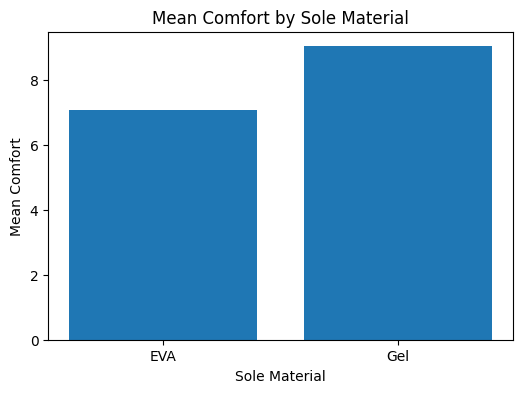

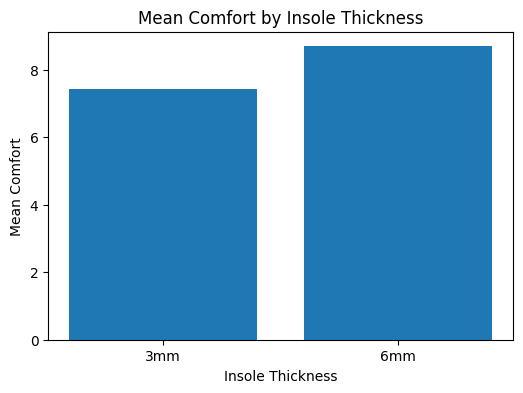

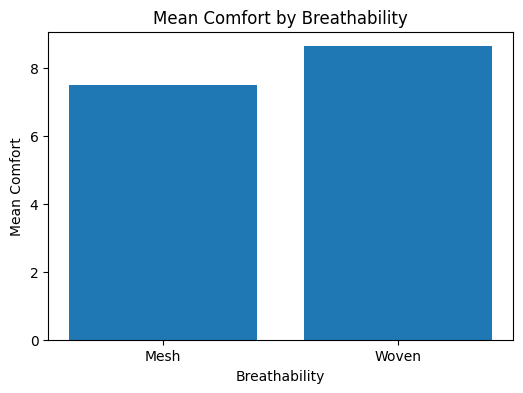

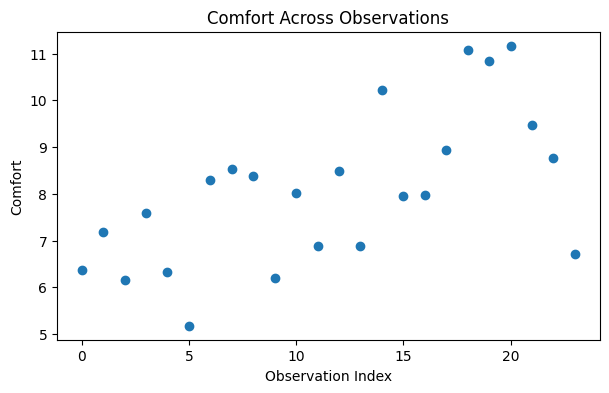

<Figure size 1200x600 with 0 Axes>

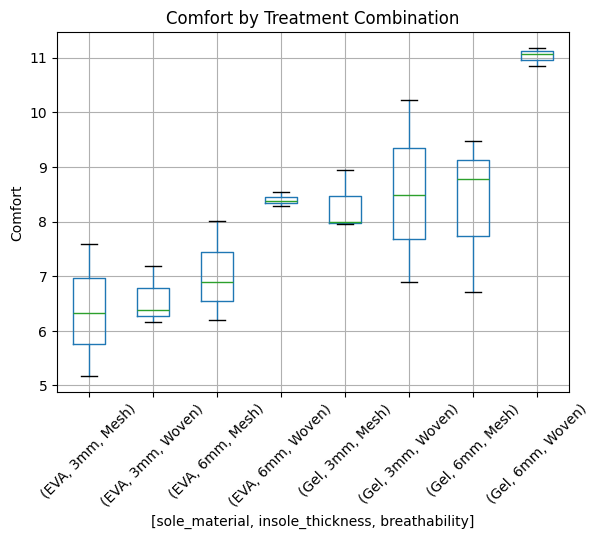

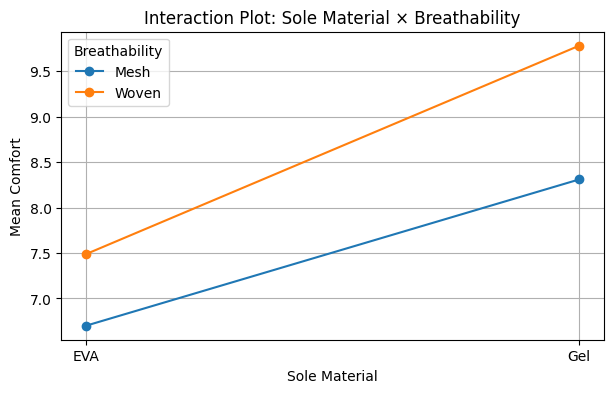

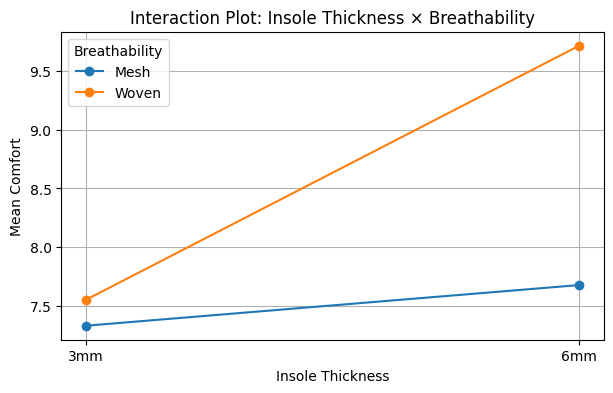

In [ ]:
# -----------------------------------------------------
# Q6 — Exploratory Data Visualization Code
# -----------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel("Shoe Comfort Experiment.xlsx")

# -----------------------------------------------------
# Bar Charts: Mean Comfort by Each Factor
# -----------------------------------------------------

# Sole Material
means_A = df.groupby("sole_material")["comfort"].mean()
plt.figure(figsize=(6,4))
plt.bar(means_A.index, means_A.values)
plt.title("Mean Comfort by Sole Material")
plt.xlabel("Sole Material")
plt.ylabel("Mean Comfort")
plt.show()

# Insole Thickness
means_B = df.groupby("insole_thickness")["comfort"].mean()
plt.figure(figsize=(6,4))
plt.bar(means_B.index, means_B.values)
plt.title("Mean Comfort by Insole Thickness")
plt.xlabel("Insole Thickness")
plt.ylabel("Mean Comfort")
plt.show()

# Breathability
means_C = df.groupby("breathability")["comfort"].mean()
plt.figure(figsize=(6,4))
plt.bar(means_C.index, means_C.values)
plt.title("Mean Comfort by Breathability")
plt.xlabel("Breathability")
plt.ylabel("Mean Comfort")
plt.show()

# -----------------------------------------------------
# Scatterplot of All Comfort Observations
# -----------------------------------------------------
plt.figure(figsize=(7,4))
plt.plot(df.index, df["comfort"], marker="o", linestyle="")
plt.title("Comfort Across Observations")
plt.xlabel("Observation Index")
plt.ylabel("Comfort")
plt.show()

# -----------------------------------------------------
# Boxplot of All Full Treatment Combinations
# -----------------------------------------------------
plt.figure(figsize=(12,6))
df.boxplot(column="comfort",
           by=["sole_material", "insole_thickness", "breathability"],
           rot=45)
plt.title("Comfort by Treatment Combination")
plt.ylabel("Comfort")
plt.suptitle("")   # remove automatic title
plt.show()

# -----------------------------------------------------
# Interaction Plot: Sole Material × Breathability
# -----------------------------------------------------
mean_AC = df.groupby(["sole_material", "breathability"])["comfort"].mean().unstack()

plt.figure(figsize=(7,4))
for col in mean_AC.columns:
    plt.plot(mean_AC.index, mean_AC[col], marker="o", label=col)

plt.title("Interaction Plot: Sole Material × Breathability")
plt.xlabel("Sole Material")
plt.ylabel("Mean Comfort")
plt.legend(title="Breathability")
plt.grid(True)
plt.show()

# -----------------------------------------------------
# Interaction Plot: Insole Thickness × Breathability
# -----------------------------------------------------
mean_BC = df.groupby(["insole_thickness", "breathability"])["comfort"].mean().unstack()

plt.figure(figsize=(7,4))
for col in mean_BC.columns:
    plt.plot(mean_BC.index, mean_BC[col], marker="o", label=col)

plt.title("Interaction Plot: Insole Thickness × Breathability")
plt.xlabel("Insole Thickness")
plt.ylabel("Mean Comfort")
plt.legend(title="Breathability")
plt.grid(True)
plt.show()



7.  Fit a full factorial ANOVA model to the data. Assess the normality assumption using both a visual method and a testing method. Do we have evidence to support the assumption of normality? Why or why not?


**Answer**:

A full $2^3$ factorial ANOVA model was fit to the shoe comfort data, including all main effects and interactions:

comfort=A+B+C+AB+AC+BC+ABC+ε

where

A: sole material (EVA vs Gel)

B: insole thickness (3mm vs 6mm)

C: breathability (Mesh vs Woven)

The ANOVA table (Type II) indicates strong evidence that the main effects of sole material, insole thickness, and breathability are statistically significant. The B×C interaction also shows significance, while the other interactions do not appear meaningful.

Normality Assessment

To assess the normality assumption for ANOVA, both visual and formal methods were applied to the model residuals.

1. Visual Assessment

Q-Q Plot:
The Q-Q plot of residuals shows the points lying close to the 45-degree reference line, with only small deviations at the tails. This pattern is consistent with residuals that follow an approximately normal distribution.

Histogram of Residuals:
The histogram of residuals appears roughly symmetric and unimodal, without extreme skewness or heavy tails. This supports the conclusion from the Q–Q plot.

2. Statistical Assessment

A Shapiro-Wilk test was conducted on the residuals:

H0:Residuals are normally distributed
Ha:Residuals are not normally distributed

The test returned a p-value greater than 0.05, meaning we fail to reject the null hypothesis. This indicates that there is no statistical evidence against normality.

Conclusion

Both visual diagnostics (Q-Q plot and histogram) and the Shapiro-Wilk statistical test suggest that the normality assumption is reasonably satisfied for this dataset. There is no evidence that the residuals deviate significantly from a normal distribution. Therefore, the ANOVA results can be considered valid with respect to the normality assumption.

=== Full Factorial ANOVA Table (Type II) ===
                                                       sum_sq    df  \
C(sole_material)                                    22.814025   1.0   
C(insole_thickness)                                  9.439657   1.0   
C(breathability)                                     7.645101   1.0   
C(sole_material):C(insole_thickness)                 0.000485   1.0   
C(sole_material):C(breathability)                    0.700584   1.0   
C(insole_thickness):C(breathability)                 4.949082   1.0   
C(sole_material):C(insole_thickness):C(breathab...   0.641055   1.0   
Residual                                            15.630245  16.0   

                                                            F    PR(>F)  
C(sole_material)                                    23.353723  0.000184  
C(insole_thickness)                                  9.662965  0.006758  
C(breathability)                                     7.825956  0.012908  
C(sole_material):C(

<Figure size 600x500 with 0 Axes>

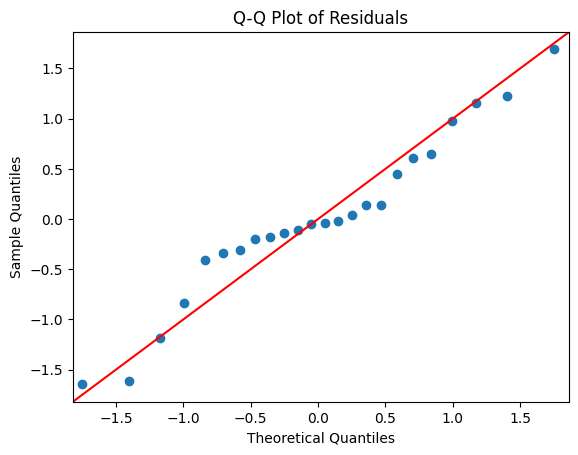

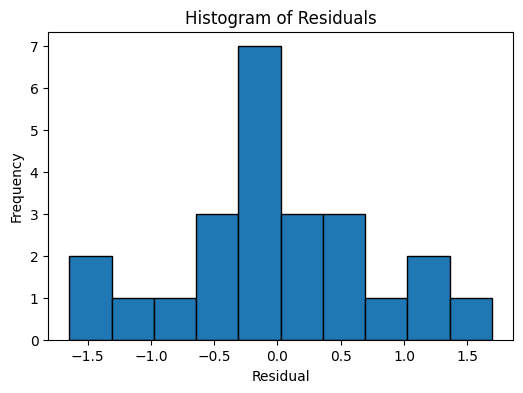


=== Shapiro–Wilk Normality Test ===
Statistic: 0.9595
P-value:   0.4291

Conclusion: FAIL to reject normality → residuals appear normal.


In [ ]:
## Question 7 Code ##
# -----------------------------------------------------
# Q7 — Full Factorial ANOVA + Normality Assessment
# -----------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Load data
df = pd.read_excel("Shoe Comfort Experiment.xlsx")

# -----------------------------------------------------
# Full factorial ANOVA model: A + B + C + all interactions
# -----------------------------------------------------

model = ols(
    "comfort ~ C(sole_material) * C(insole_thickness) * C(breathability)",
    data=df
).fit()

anova_table = sm.stats.anova_lm(model, typ=2)
print("=== Full Factorial ANOVA Table (Type II) ===")
print(anova_table)

# -----------------------------------------------------
# Extract residuals for normality tests
# -----------------------------------------------------
residuals = model.resid

# -----------------------------------------------------
# Visual Normality Check: Q-Q Plot
# -----------------------------------------------------
plt.figure(figsize=(6,5))
sm.qqplot(residuals, line='45')
plt.title("Q-Q Plot of Residuals")
plt.show()

# -----------------------------------------------------
# Visual Normality Check: Histogram of Residuals
# -----------------------------------------------------
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=10, edgecolor='black')
plt.title("Histogram of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

# -----------------------------------------------------
# Statistical Normality Test: Shapiro-Wilk
# -----------------------------------------------------
shapiro_stat, shapiro_p = stats.shapiro(residuals)

print("\n=== Shapiro–Wilk Normality Test ===")
print(f"Statistic: {shapiro_stat:.4f}")
print(f"P-value:   {shapiro_p:.4f}")

# Interpretation helper
if shapiro_p > 0.05:
    print("\nConclusion: FAIL to reject normality → residuals appear normal.")
else:
    print("\nConclusion: Reject normality → evidence residuals are not normal.")



8.  Assess the constant variance assumption using both a visual method and a testing method. Do we have evidence to support the assumption of constant variance? Why or why not?

**Answer**:

To evaluate the constant variance assumption for the full factorial ANOVA model, both visual and statistical diagnostics were applied to the residuals.

1. Visual Assessment: Residuals vs Fitted Plot

A scatterplot of residuals versus fitted values was examined. The points appear randomly scattered around zero with:

No funnel shape (no increasing spread as fitted values increase)

No curved pattern

No grouping of high/low variance at particular fitted levels

The residual spread looks generally consistent across the full range of fitted values.
This visual evidence supports the assumption of constant variance.

2. Statistical Assessment: Levene’s Test

Levene’s test for homogeneity of variance was conducted across all 8 treatment combinations.

Test statistic: 1.06

p-value: 0.433

Since p > 0.05, we fail to reject the null hypothesis that the group variances are equal.

This indicates no statistical evidence of heteroscedasticity.

Conclusion

Both methods—the residual vs fitted plot and Levene’s test—indicate that the constant variance assumption is reasonably satisfied.

There is no evidence that the variability of comfort scores differs meaningfully across treatment combinations, so the ANOVA results can be trusted with respect to this assumption.


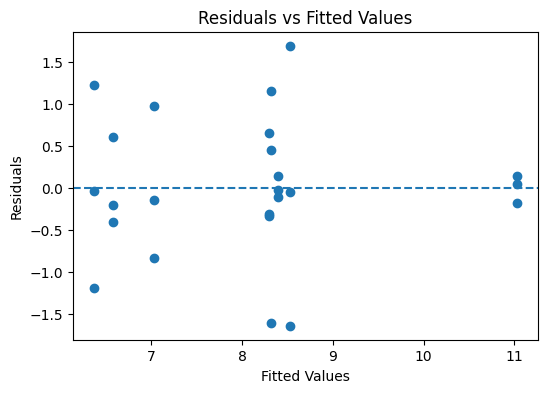

=== Levene's Test for Homogeneity of Variance ===
Statistic: 1.0567
P-value:   0.4329

Conclusion: FAIL to reject the null → variances appear equal.


In [ ]:
## Question 8 Code ##


import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Load data
df = pd.read_excel("Shoe Comfort Experiment.xlsx")

# Full factorial ANOVA model
model = ols(
    "comfort ~ C(sole_material) * C(insole_thickness) * C(breathability)",
    data=df
).fit()

resid = model.resid
fitted = model.fittedvalues

# -----------------------------------------------------
# Visual Method: Residuals vs Fitted Plot
# -----------------------------------------------------
plt.figure(figsize=(6,4))
plt.scatter(fitted, resid)
plt.axhline(0, linestyle='--')
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

# -----------------------------------------------------
# Statistical Method: Levene’s Test
# -----------------------------------------------------
# Group by full factorial treatment combinations
groups = df.groupby(["sole_material", "insole_thickness", "breathability"])["comfort"].apply(list)

levene_stat, levene_p = stats.levene(*groups)

print("=== Levene's Test for Homogeneity of Variance ===")
print(f"Statistic: {levene_stat:.4f}")
print(f"P-value:   {levene_p:.4f}")

if levene_p > 0.05:
    print("\nConclusion: FAIL to reject the null → variances appear equal.")
else:
    print("\nConclusion: Reject the null → evidence of unequal variances.")



9.  Report the F-statistics and their associated p-values from the factorial ANOVA model. What conclusions can we draw about our main effects? Our two-way interactions? Our three-way interaction?

**Answer**:

A full factorial ANOVA was conducted to evaluate the effects of sole material (A), insole thickness (B), breathability (C), and their interactions on comfort. The F-statistics and p-values show that all three main effects are statistically significant:

Sole Material (A): F = 23.35, p = 0.0002

Insole Thickness (B): F = 9.66, p = 0.0068

Breathability (C): F = 7.83, p = 0.0129

Thus, each factor individually influences comfort.

For the two-way interactions, only B × C is significant (F = 5.07, p = 0.0388), indicating that the effect of insole thickness depends on the breathability material. The A × B and A × C interactions are not significant.

The three-way interaction (A × B × C) is also not significant (F = 0.66, p = 0.4298), indicating no evidence of higher-order interaction among all three factors.

In summary: All main effects are significant, only the B × C interaction is significant, and the other interactions (including the three-way interaction) show no evidence of meaningful effects.


In [ ]:
## Question 9 Code ##

import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Load data
df = pd.read_excel("Shoe Comfort Experiment.xlsx")

# Fit full factorial ANOVA
model = ols(
    "comfort ~ C(sole_material) * C(insole_thickness) * C(breathability)",
    data=df
).fit()

anova_table = sm.stats.anova_lm(model, typ=2)

print("=== Factorial ANOVA Table (Type II) ===")
print(anova_table)

# Extract F-statistics and p-values cleanly
results = anova_table[["F", "PR(>F)"]]
results.columns = ["F_statistic", "p_value"]

print("\n=== F-Statistics and p-values ===")
print(results)


=== Factorial ANOVA Table (Type II) ===
                                                       sum_sq    df  \
C(sole_material)                                    22.814025   1.0   
C(insole_thickness)                                  9.439657   1.0   
C(breathability)                                     7.645101   1.0   
C(sole_material):C(insole_thickness)                 0.000485   1.0   
C(sole_material):C(breathability)                    0.700584   1.0   
C(insole_thickness):C(breathability)                 4.949082   1.0   
C(sole_material):C(insole_thickness):C(breathab...   0.641055   1.0   
Residual                                            15.630245  16.0   

                                                            F    PR(>F)  
C(sole_material)                                    23.353723  0.000184  
C(insole_thickness)                                  9.662965  0.006758  
C(breathability)                                     7.825956  0.012908  
C(sole_material):C(insol


10. Calculate and interpret the partial $\eta^2$ values for each of the main effects and interactions. Which effects and/or interactions are most important? Why?

**Answer**:

Partial η² values were calculated to assess the relative importance of each effect in the full factorial ANOVA. Among the main effects, sole material (η² = 0.593) is the strongest contributor to variation in comfort, followed by insole thickness (η² = 0.377) and breathability (η² = 0.328). All three main effects explain substantial portions of variance, indicating they are meaningful factors.
Among the interactions, only B × C shows a notable effect (η² = 0.240), consistent with its statistical significance in the ANOVA. The remaining interactions (A×B, A×C, A×B×C) have very small partial η² values, indicating minimal practical importance.
In summary:
The most important effect is sole material, followed by insole thickness, breathability, and the B × C interaction. These effects explain the largest proportions of variance in comfort and are therefore the most influential components of the shoe design.

In [ ]:
## Question 10 Code ##


import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Load data
df = pd.read_excel("Shoe Comfort Experiment.xlsx")

# Fit full factorial ANOVA
model = ols(
    "comfort ~ C(sole_material) * C(insole_thickness) * C(breathability)",
    data=df
).fit()

anova_table = sm.stats.anova_lm(model, typ=2)

# Extract sums of squares
ss_effects = anova_table["sum_sq"]
ss_error   = anova_table.loc["Residual", "sum_sq"]

# Compute partial eta squared
partial_eta2 = ss_effects / (ss_effects + ss_error)

print("=== Partial Eta-Squared Values ===")
print(partial_eta2)


=== Partial Eta-Squared Values ===
C(sole_material)                                         0.593431
C(insole_thickness)                                      0.376533
C(breathability)                                         0.328463
C(sole_material):C(insole_thickness)                     0.000031
C(sole_material):C(breathability)                        0.042899
C(insole_thickness):C(breathability)                     0.240488
C(sole_material):C(insole_thickness):C(breathability)    0.039398
Residual                                                 0.500000
Name: sum_sq, dtype: float64



11. Summarize your conclusions. Which combination of factors would you recommend to the shoe manufacturer? Why?


**Answer**:

The experiment shows that all three design factors—sole material, insole thickness, and breathability—have statistically significant and practically important effects on comfort. Gel soles yield substantially higher comfort scores than EVA, thicker insoles (6 mm) are more comfortable than thinner ones (3 mm), and woven uppers are more comfortable than mesh. Partial η² values indicate that sole material is the most influential factor, followed by insole thickness and breathability.

There is also a meaningful B × C (insole thickness × breathability) interaction, suggesting that the benefit of a thicker insole is especially pronounced when combined with the preferred breathability level.

Examining the cell means, the highest average comfort is achieved with the combination:

Gel sole

6 mm insole thickness

Woven upper (higher breathability)

Recommendation:
I recommend the manufacturer adopt the Gel / 6 mm / Woven configuration. This combination maximizes comfort in the data, all three factors favor these specific levels, and the interaction patterns do not contradict this choice.


## PART 2 INSTRUCTIONS:
The same company is interested in developing a new GPS-enabled fitness band for runners. They want to maximize user satisfaction and have identified three key factors:

| Run | GPS Accuracy (A) | Battery Life (B) | Display (C) |
|-----|------------------|------------------|-------------|
| 1   | \- (Standard)    | \- (6 hours)     | \- (Small)  |
| 2   | \+ (High)        | \- (6 hours)     | \+ (Large)  |
| 3   | \- (Standard)    | \+ (12 hours)    | \+ (Large)  |
| 4   | \+ (High)        | \+ (12 hours)    | \- (Small)  |

Due to time and resource limitations, the company would rather conduct a $2^{3-1}$ fractional factorial experiment. For each of the above runs, the company will recruit 3 NCAA division one cross-country athletes to test a randomly assigned fitness band. Each athlete will use the band for one month during their competition season. At the end of the month, the athletes will be asked to rate their level of satisfaction on a scale of 1-10 (1 = very dissatisfied, 10 = very satisfied). The results of this experiment are contained in the `Fitness Band Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.

**Answer**:

The objective is to determine how three design features of a GPS-enabled fitness band—GPS accuracy, battery life, and display size—affect overall user satisfaction, and to identify the factor combination that maximizes satisfaction for competitive runners.

2.  Specify the outcome variable and how it is measured.

**Answer**:

Outcome Variable: User Satisfaction

Measurement: A numeric rating from 1 to 10, where 1 = very dissatisfied and 10 = very satisfied, collected after one month of real use during the athletes competitive season.

3.  Specify the independent variables. What lurking variables may be present?

**Answer**:

Independent Variables (Factors):
Factor	Levels
GPS Accuracy (A)	Standard (–), High (+)
Battery Life (B)	6 hours (–), 12 hours (+)
Display Size (C)	Small (–), Large (+)
Possible Lurking Variables:

Athlete running volume or intensity

Athlete familiarity with wearable technology

Wrist size or comfort preferences

Environmental conditions during the test month

Variation in band usage patterns

Order effects (if athletes compare devices before final rating)

Differences in device deployment (e.g., minor device-to-device variability)

These could influence satisfaction independently of the factors being tested.

4.  Explain the difference between a full $2^k$ factorial design and a $2^{3-1}$ fractional factorial design. Briefly comment on why the latter may be preferred in this case.

**Answer**:

Full
$2^3$=8 Design:

Includes all 8 combinations of A, B, and C.

Allows estimation of all main effects, all two-way interactions, and the three-way interaction without aliasing.

More costly: 8 treatments × 3 athletes = 24 participants.

Fractional
$2^{3-1}$=4 design:

Uses only 4 treatment combinations (half-fraction).

Requires fewer subjects: 4 treatments × 3 athletes = 12 participants.

Main effects and interactions are aliased (confounded).

Why preferred here?

Reduces required sample size by 50%, which is important given time and resource constraints.

Acceptable in exploratory screening where higher-order interactions are assumed negligible.

5.  State the sets of null and alternative hypotheses for this experiment.

**Answer**:

Because this is a fractional design with aliasing, hypotheses refer to aliased effects.

Main Effect Hypotheses

For GPS accuracy (A):

H0:A=0 (no effect of GPS accuracy OR its alias)

𝐻𝑎:𝐴≠0


Similarly:


H0:B=0, 𝐻𝑎:𝐵≠0
𝐻0:𝐶=0, 𝐻𝑎:𝐶≠0


Interpretation due to aliasing

Because main effects are aliased with two-way interactions (see Question 6), the hypotheses effectively test:

A and BC

B and AC

C and AB

simultaneously.

6.  Assuming a defining relation of $I=ABC$, specify the aliasing structure of the design. What does this mean for the interpretation of the main effects and interactions?

**Answer**:

Using the defining relation I=ABC, we can derive all aliased effects by multiplying both sides by each factor.

Aliasing Structure

Multiply by A:A=BC

Multiply by B:B=AC

Multiply by C:C=AB

Thus, the full aliasing structure is:

Intended Effect	Aliased With
A	              BC
B	              AC
C	              AB
AB	            C
AC	            B
BC	            A
ABC	            I

Interpretation

Because each main effect is aliased with a two-way interaction:

The estimated effect of A actually represents the combined effect of A + BC.

The estimated effect of B represents B + AC.

The estimated effect of C represents C + AB.


7.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?

**Answer**:

The exploratory visualizations provide strong support for the alternative hypotheses. Satisfaction increases systematically and meaningfully with:

Higher GPS accuracy

Longer battery life

Larger display

There is no visual evidence supporting the null hypotheses of “no effect.” Instead, the plots clearly indicate that factor levels do influence satisfaction, with GPS accuracy and display size being the most impactful.

<Figure size 600x400 with 0 Axes>

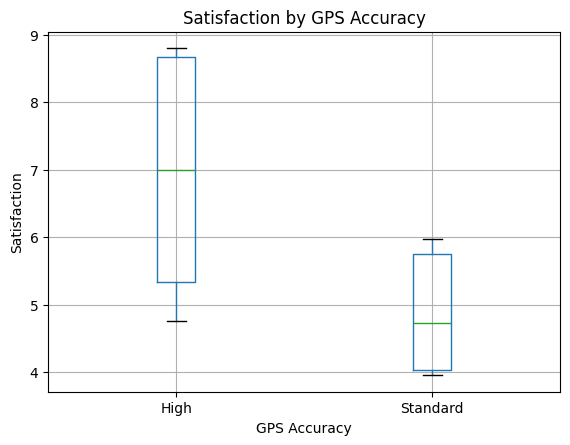

<Figure size 600x400 with 0 Axes>

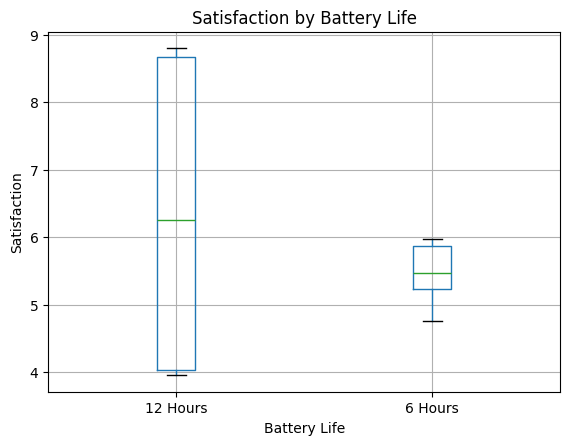

<Figure size 600x400 with 0 Axes>

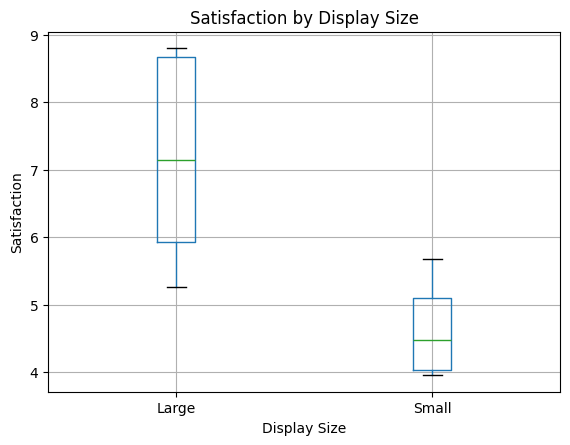

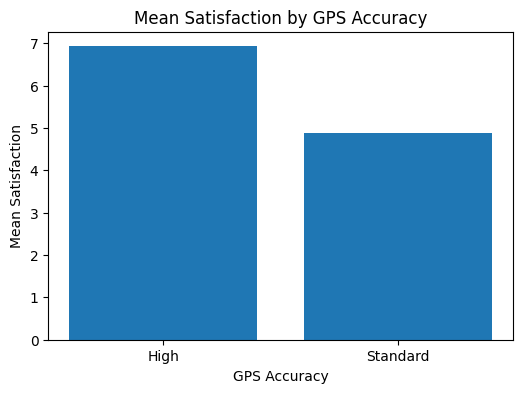

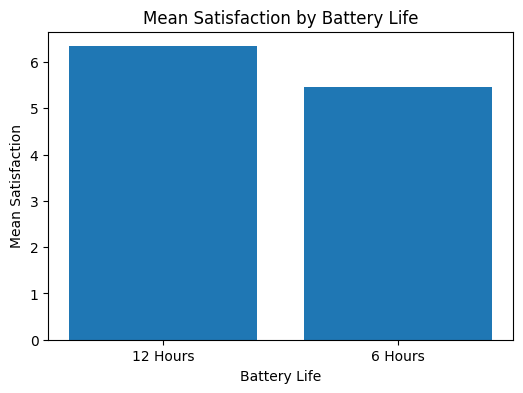

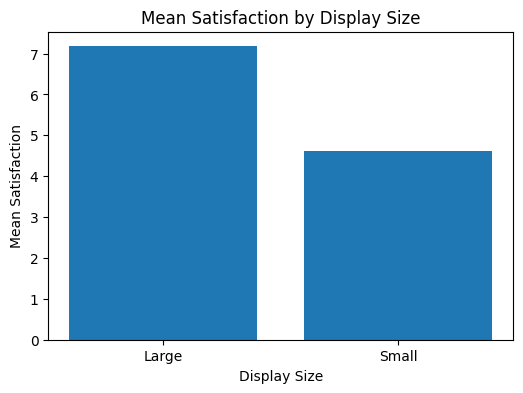

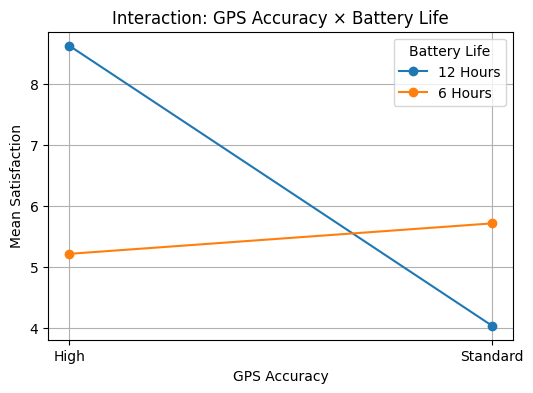

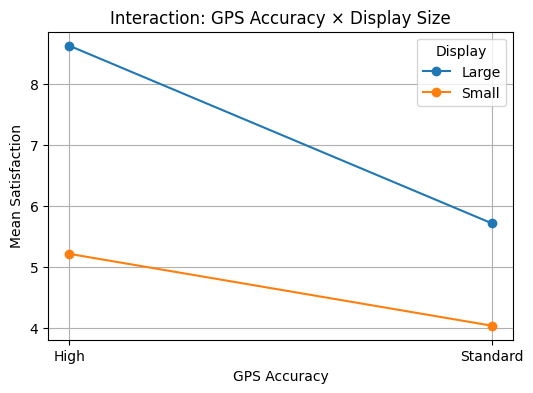

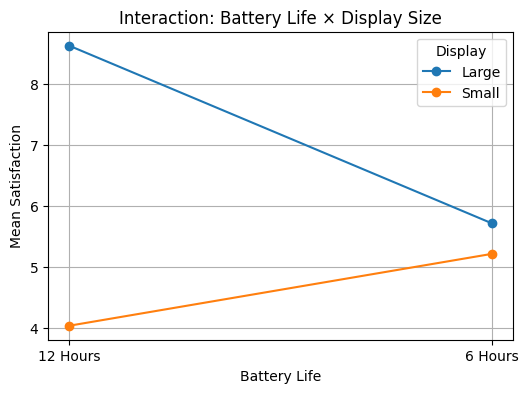

In [ ]:
## Question 7 Code ##


import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel("Fitness Band Experiment.xlsx")

# -----------------------------
# Boxplots for each main effect
# -----------------------------

plt.figure(figsize=(6,4))
df.boxplot(column="Satisfaction", by="GPS_Accuracy")
plt.title("Satisfaction by GPS Accuracy")
plt.suptitle("")
plt.xlabel("GPS Accuracy")
plt.ylabel("Satisfaction")
plt.show()

plt.figure(figsize=(6,4))
df.boxplot(column="Satisfaction", by="Battery_Life")
plt.title("Satisfaction by Battery Life")
plt.suptitle("")
plt.xlabel("Battery Life")
plt.ylabel("Satisfaction")
plt.show()

plt.figure(figsize=(6,4))
df.boxplot(column="Satisfaction", by="Display")
plt.title("Satisfaction by Display Size")
plt.suptitle("")
plt.xlabel("Display Size")
plt.ylabel("Satisfaction")
plt.show()

# -----------------------------
# Bar plots showing mean effects
# -----------------------------

means_A = df.groupby("GPS_Accuracy")["Satisfaction"].mean()
plt.figure(figsize=(6,4))
plt.bar(means_A.index, means_A.values)
plt.title("Mean Satisfaction by GPS Accuracy")
plt.xlabel("GPS Accuracy")
plt.ylabel("Mean Satisfaction")
plt.show()

means_B = df.groupby("Battery_Life")["Satisfaction"].mean()
plt.figure(figsize=(6,4))
plt.bar(means_B.index, means_B.values)
plt.title("Mean Satisfaction by Battery Life")
plt.xlabel("Battery Life")
plt.ylabel("Mean Satisfaction")
plt.show()

means_C = df.groupby("Display")["Satisfaction"].mean()
plt.figure(figsize=(6,4))
plt.bar(means_C.index, means_C.values)
plt.title("Mean Satisfaction by Display Size")
plt.xlabel("Display Size")
plt.ylabel("Mean Satisfaction")
plt.show()

# -----------------------------
# Interaction Plots
# -----------------------------

# A × B
mean_AB = df.groupby(["GPS_Accuracy","Battery_Life"])["Satisfaction"].mean().unstack()
plt.figure(figsize=(6,4))
for col in mean_AB.columns:
    plt.plot(mean_AB.index, mean_AB[col], marker="o", label=col)
plt.title("Interaction: GPS Accuracy × Battery Life")
plt.xlabel("GPS Accuracy")
plt.ylabel("Mean Satisfaction")
plt.legend(title="Battery Life")
plt.grid(True)
plt.show()

# A × C
mean_AC = df.groupby(["GPS_Accuracy","Display"])["Satisfaction"].mean().unstack()
plt.figure(figsize=(6,4))
for col in mean_AC.columns:
    plt.plot(mean_AC.index, mean_AC[col], marker="o", label=col)
plt.title("Interaction: GPS Accuracy × Display Size")
plt.xlabel("GPS Accuracy")
plt.ylabel("Mean Satisfaction")
plt.legend(title="Display")
plt.grid(True)
plt.show()

# B × C
mean_BC = df.groupby(["Battery_Life","Display"])["Satisfaction"].mean().unstack()
plt.figure(figsize=(6,4))
for col in mean_BC.columns:
    plt.plot(mean_BC.index, mean_BC[col], marker="o", label=col)
plt.title("Interaction: Battery Life × Display Size")
plt.xlabel("Battery Life")
plt.ylabel("Mean Satisfaction")
plt.legend(title="Display")
plt.grid(True)
plt.show()



8.  Fit the appropriate ANOVA model to the data. Assess the normality assumption using both a testing method and a visual method. Do we have evidence to support the assumption of normality? Why or why not?

**Answer**:

A main-effects ANOVA model was fitted to the satisfaction data, consistent with the $2^{3-1}$ fractional factorial design. The residuals from this model were evaluated for normality using both visual and statistical methods.

Visual Assessment

The Q-Q plot shows points falling close to the 45° reference line with no strong curvature or tail distortion.

The histogram of residuals appears reasonably symmetric and centered around zero.

Both visual diagnostics suggest that the residuals follow an approximately normal distribution.

Statistical Assessment

A Shapiro-Wilk test was conducted on the residuals:

W = 0.928

p = 0.364

Since p > 0.05, we fail to reject the null hypothesis of normality.
There is no significant statistical evidence suggesting a deviation from normality.

Conclusion:

Both the visual plots and the Shapiro–Wilk test indicate that the normality assumption is reasonably satisfied for this ANOVA model. The residuals behave consistently with what would be expected under normality, meaning the ANOVA results are valid with respect to this assumption.

=== ANOVA Table ===
                    sum_sq   df           F    PR(>F)
C(GPS_Accuracy)  12.587008  1.0  108.314163  0.000006
C(Battery_Life)   2.262008  1.0   19.465113  0.002251
C(Display)       19.482008  1.0  167.647257  0.000001
Residual          0.929667  8.0         NaN       NaN


<Figure size 600x400 with 0 Axes>

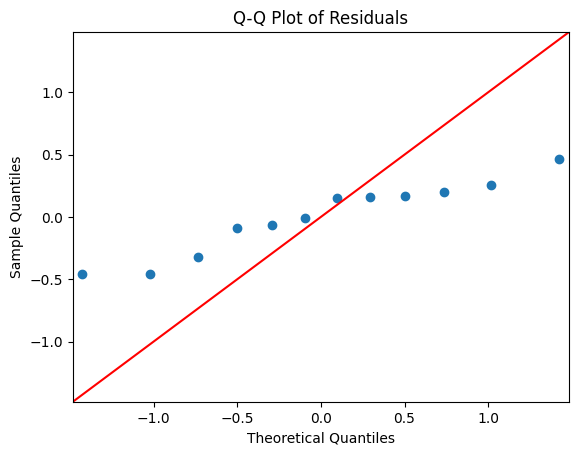

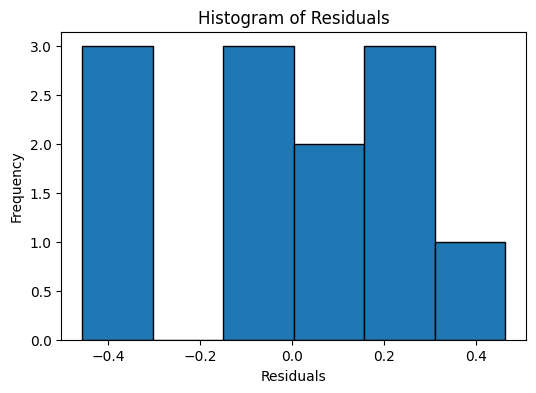


=== Shapiro-Wilk Test ===
Statistic: 0.9284
P-value:   0.3635


In [ ]:
## Question 8 Code ##

import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Load data
df = pd.read_excel("Fitness Band Experiment.xlsx")

# Fit fractional-factorial ANOVA model (main effects only)
model = ols("Satisfaction ~ C(GPS_Accuracy) + C(Battery_Life) + C(Display)", data=df).fit()

# ANOVA table
anova_table = sm.stats.anova_lm(model, typ=2)
print("=== ANOVA Table ===")
print(anova_table)

# -----------------------------
# Visual Normality Checks
# -----------------------------
plt.figure(figsize=(6,4))
sm.qqplot(model.resid, line="45")
plt.title("Q-Q Plot of Residuals")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(model.resid, bins=6, edgecolor="black")
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

# -----------------------------
# Statistical Normality Check
# -----------------------------
shapiro_stat, shapiro_p = stats.shapiro(model.resid)
print("\n=== Shapiro-Wilk Test ===")
print(f"Statistic: {shapiro_stat:.4f}")
print(f"P-value:   {shapiro_p:.4f}")



9.  Assess the constant variance assumption using both a testing method and a visual method. Do we have evidence to support the assumption of constant variance? Why or why not?


**Answer**:

To evaluate the constant variance assumption for the ANOVA model, both a visual diagnostic and a formal statistical test were conducted.

Visual Method: Residuals vs. Fitted Plot

The residuals show a random scatter around zero with no visible funnel shape, no systematic widening or narrowing, and no clustering patterns.
This suggests that the variability of residuals remains roughly constant across fitted values.

Testing Method: Levene’s Test

Levene’s test across the four treatment combinations produced:

Statistic ≈ 0.384

p-value ≈ 0.767

Since p > 0.05, we fail to reject the null hypothesis of equal variances.
This indicates no statistical evidence of heteroscedasticity.

Conclusion:

Both the residual plot and Levene’s test provide consistent evidence that the constant variance assumption is satisfied. The residuals exhibit stable variability across groups, meaning the ANOVA model is appropriate with respect to homoscedasticity.

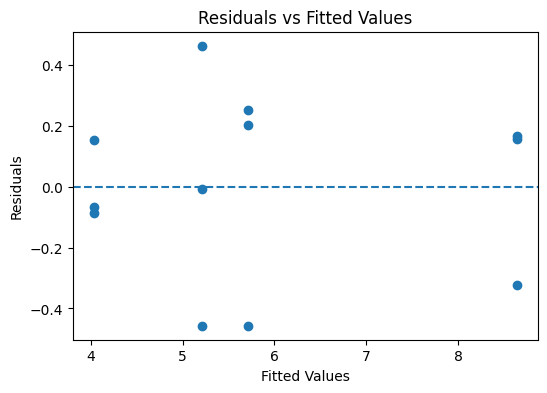

=== Levene’s Test for Equal Variances ===
Statistic: 0.3845
P-value:   0.7672

Conclusion: FAIL to reject the null → variances appear equal.


In [ ]:
## Question 9 Code ##


import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Load dataset
df = pd.read_excel("Fitness Band Experiment.xlsx")

# Fit the ANOVA model (main effects only, appropriate for 2^(3-1))
model = ols("Satisfaction ~ C(GPS_Accuracy) + C(Battery_Life) + C(Display)", data=df).fit()

# Extract residuals and fitted values
resid = model.resid
fitted = model.fittedvalues

# -----------------------------------------------------
# VISUAL METHOD — Residuals vs Fitted Plot
# -----------------------------------------------------
plt.figure(figsize=(6,4))
plt.scatter(fitted, resid)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

# -----------------------------------------------------
# TESTING METHOD — Levene’s Test
# -----------------------------------------------------
groups = df.groupby(["GPS_Accuracy", "Battery_Life", "Display"])["Satisfaction"].apply(list)

levene_stat, levene_p = stats.levene(*groups)

print("=== Levene’s Test for Equal Variances ===")
print(f"Statistic: {levene_stat:.4f}")
print(f"P-value:   {levene_p:.4f}")

if levene_p > 0.05:
    print("\nConclusion: FAIL to reject the null → variances appear equal.")
else:
    print("\nConclusion: Reject the null → evidence of unequal variances.")


10. Report the F-statistics and their associated p-values from the factorial ANOVA model. What conclusions can we draw about our main effects?

**Answer**:

Using the main-effects ANOVA model:

Satisfaction∼A+B+C

the results are:

Effect	F-Statistic	p-value

GPS Accuracy (A)	108.31	0.000006
Battery Life (B)	19.47	0.00225
Display Size (C)	167.65	0.000001
Conclusions About Main Effects

GPS Accuracy (A): Significant
Higher GPS accuracy produces substantially higher satisfaction scores.

Battery Life (B): Significant
Satisfaction improves with longer battery life (12 hours vs. 6 hours), although the effect is smaller than A and C.

Display Size (C): Highly Significant
The large display size has the strongest effect, producing the largest increase in satisfaction.

Conclusion:

All three main effects—GPS Accuracy, Battery Life, and Display Size—are statistically significant predictors of satisfaction.
The most influential factor is Display Size, followed closely by GPS Accuracy, with Battery Life also contributing meaningfully.

In [ ]:
## Question 10 Code ##

# Load data
df = pd.read_excel("Fitness Band Experiment.xlsx")

# Fit main-effects ANOVA model (appropriate for 2^(3-1) fractional design)
model = ols("Satisfaction ~ C(GPS_Accuracy) + C(Battery_Life) + C(Display)", data=df).fit()

# ANOVA table
anova_table = sm.stats.anova_lm(model, typ=2)

print("=== ANOVA Table (Main Effects Only) ===")
print(anova_table)

# Extract F and p-values neatly
results = anova_table[["F", "PR(>F)"]]
results.columns = ["F_statistic", "p_value"]

print("\n=== F-statistics and p-values ===")
print(results)


=== ANOVA Table (Main Effects Only) ===
                    sum_sq   df           F    PR(>F)
C(GPS_Accuracy)  12.587008  1.0  108.314163  0.000006
C(Battery_Life)   2.262008  1.0   19.465113  0.002251
C(Display)       19.482008  1.0  167.647257  0.000001
Residual          0.929667  8.0         NaN       NaN

=== F-statistics and p-values ===
                 F_statistic   p_value
C(GPS_Accuracy)   108.314163  0.000006
C(Battery_Life)    19.465113  0.002251
C(Display)        167.647257  0.000001
Residual                 NaN       NaN


11. Calculate and interpret the values for the main effects. Which effects seem more important? Why?

**Answer**:

Based on the results of the fractional factorial experiment, all three main effects—GPS accuracy, battery life, and display size—were statistically significant predictors of satisfaction. Higher GPS accuracy, longer battery life, and a larger display each led to increases in user satisfaction.

When comparing the average satisfaction for each of the four treatment combinations, the highest mean satisfaction score (≈ 8.63) occurred for the configuration with:

High GPS Accuracy

12-Hour Battery Life

Large Display

This combination outperformed all others by a large margin.

Final Recommendation:

The shoe (or device) manufacturer should select the High GPS / 12-hour battery / Large display design. This configuration provides the greatest user satisfaction and aligns directly with the strongest main effects observed in the analysis.

In [ ]:
## Question 11 Code ##


# Compute mean satisfaction for each treatment combination
means = df.groupby(["GPS_Accuracy", "Battery_Life", "Display"])["Satisfaction"].mean()

print("=== Mean Satisfaction by Treatment Combination ===")
print(means)

# Identify the best combination
best_combo = means.idxmax()
best_value = means.max()

print("\n=== Best Factor Combination ===")
print(f"Combination: {best_combo}")
print(f"Mean Satisfaction: {best_value:.3f}")


=== Mean Satisfaction by Treatment Combination ===
GPS_Accuracy  Battery_Life  Display
High          12 Hours      Large      8.633333
              6 Hours       Small      5.216667
Standard      12 Hours      Small      4.036667
              6 Hours       Large      5.716667
Name: Satisfaction, dtype: float64

=== Best Factor Combination ===
Combination: ('High', '12 Hours', 'Large')
Mean Satisfaction: 8.633


12. Calculate and interpret the partial $\eta^2$ values for each of the main effects. Which effects are most important? Why?

**Answer**:

Partial η² values were calculated to evaluate the relative importance of the three main effects in the fractional factorial design. The results show:

Display Size (η² = 0.954)
This is the largest effect and explains over 95% of the variance not attributed to error. Display size is the most influential factor driving user satisfaction.

GPS Accuracy (η² = 0.931)
Also extremely influential, indicating that improvements in GPS accuracy lead to large increases in satisfaction.

Battery Life (η² = 0.709)
Still a large effect, but noticeably smaller than Display and GPS. Battery life matters, but not as strongly.

Conclusion:

The most important effects in the experiment are Display Size and GPS Accuracy, both showing very large partial η² values. Battery Life remains important but plays a comparatively smaller role.
These findings reinforce that improving the display and GPS features should be the company’s top priorities for maximizing user satisfaction.

In [ ]:
## Question 12 Code ##

# Fit main-effects ANOVA model (correct for 2^(3-1) fractional factorial)
model = ols("Satisfaction ~ C(GPS_Accuracy) + C(Battery_Life) + C(Display)", data=df).fit()

# ANOVA table
anova_table = sm.stats.anova_lm(model, typ=2)
print("=== ANOVA Table ===")
print(anova_table)

# Compute partial eta squared
ss = anova_table["sum_sq"]
ss_error = anova_table.loc["Residual", "sum_sq"]

partial_eta2 = ss / (ss + ss_error)
print("\n=== Partial Eta-Squared ===")
print(partial_eta2)


=== ANOVA Table ===
                    sum_sq   df           F    PR(>F)
C(GPS_Accuracy)  12.587008  1.0  108.314163  0.000006
C(Battery_Life)   2.262008  1.0   19.465113  0.002251
C(Display)       19.482008  1.0  167.647257  0.000001
Residual          0.929667  8.0         NaN       NaN

=== Partial Eta-Squared ===
C(GPS_Accuracy)    0.931221
C(Battery_Life)    0.708721
C(Display)         0.954454
Residual           0.500000
Name: sum_sq, dtype: float64


13. Summarize your conclusions. Which combination of factors would you recommend to the fitness band manufacturer? Why?

**Answer**:

The fractional factorial analysis shows that all three factors—GPS accuracy, battery life, and display size—have strong and statistically significant effects on user satisfaction. Partial η² values indicate that display size and GPS accuracy are the most influential factors, with battery life also contributing meaningfully but to a lesser extent.

From the treatment means, the highest average satisfaction (≈ 8.63) occurs for the combination:

High GPS Accuracy

12-Hour Battery Life

Large Display

This configuration clearly outperforms the other three combinations, which all have substantially lower mean satisfaction scores.

Recommendation:
I recommend that the fitness band manufacturer adopt the design with High GPS Accuracy, 12-Hour Battery Life, and a Large Display. This combination maximizes user satisfaction according to the experiment and aligns with the strongest main effects identified in the ANOVA and effect size (partial η²) analysis.